<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

#### **미니프로젝트 안내 메모**
+@ 는 검색을 통해서 채워라

결국엔 빅프로젝트를 위한 종합, 스스로 과제를 직접 발굴/기획/개발하는 시간
과제제출 내일 잘 내야함..? 와우
1:1문의는 하지맙시다

미션 개인과제 조별로 부족메꾸기 공동과제 수행
전체 발표 시간에 조별 솔루션을 공유 인사이트 습득
프로젝트에 따라 개인/조별 과제 제출 그리고 셀테로 마무리

손 떼면 슬픔 해보면 다 됨

데이터도 가상 데이터임 그래서 답안지가 없다는 뜻
12시까지 혼자 미션 5개 근데 하나의 미션인 셈

그리고 기본 모델링은 미션 6,7

사실상 연결 내용임

그리고 내용 공유하면서

2일차도 빡세네 일단 10페이지정도로 줄여라 내용을 줄이는 것도 중요하다



## 항공사 특징

고객경험을 가장 중요한 가치
항공 서비스를 더 중요
AI 와 데이터를 활용해 세계 최고의 고객경험

대부분의 서비스 항목에서 높은 만족도 고객만족도 평가결과도 긍정적인 수준

그러나 실제 운영현장에서는 다음과 같은 문제
고객 불만 접수 증가
공항 현장 서비스 불만 발생
온라인 후기 부정적 평가 증가
설문 데이터와 실제 고객경험 차이 발생

의문

ai기반 고객 만족도 분석 특별 프로젝트 추진 결정
고객 설문 데이터 기반으로 문제 원인 분석

AI모델 활용 고객 만족도 예측
데이터 분석을 통해 서비스 개선 방향 도출

목표1ㅣ 문제 분석

목표2ㅣ 기존 딥러닝 모델 구현 및 문제점

목표3ㅣ 추가 설문 데이터 확보
이건 내일 옴 ㅋㅋ

=> 이게 결국엔 모델만든걸로 추가 학습이 될 것

목표4ㅣ 딥러닝 모델 추가 학습 수행 => 파인 튜닝도 하기


### **고객 만족도 예측을 통한 서비스 개선**
# **단계 1: 데이터 분석**

## **미션 설명**

- 이번 단계에서는 다음과 같이 5개의 미션을 수행합니다.

### 미션 1: 기본 탐색 및 전처리

- 분석 대상 데이터를 읽어와 기본적인 탐색을 수행합니다.
- 결측치 존재 여부를 확인하고 적절한 방법으로 처리합니다.
- Target 값을 숫자로 변경합니다.
- 분석에 불필요한 변수를 제거합니다.

### 미션 2: 가설 수립과 검증

- 탐색 과정을 통해 얻은 정보로 가설을 수립합니다.
- 데이터 시각화 분석을 통해 수립한 가설을 검증합니다.
- 모든 분석 과정에 대한 의견을 정리합니다.
- 정리된 의견은 팀 프로젝트 수행 시 발표 자료에 정리합니다.


### 미션 3: 머신러닝 모델링 #1

- 머신러닝 모델을 만들어 성능을 평가합니다.
- 변수 중요도를 확인하고 의견으로 정리합니다.

### 미션 4: 머신러닝 모델링 #2

- 데이터를 두 개로 분리합니다.
- 각각의 데이터에 대해 별도의 모델을 만들어 성능을 평가합니다.
- 각각의 모델이 중요하다고 판단한 변수를 확인하고 정리합니다.

### 미션 5: 데이터 분석

- 모델링 과정을 통해 얻은 통찰력으로 분석 대상 변수를 선택합니다.
- 선택한 변수에 대한 분석을 수행하고 결과를 의견으로 정리합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 구글 드라이브에 **project01** 폴더를 만들고 배포한 파일을 업로드합니다.
- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [1]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/python/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind, pointbiserialr
import statsmodels.api as sm
from statsmodels.genmod import families


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 데이터 불러오기

- 다음 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'survey.csv' → data

In [3]:
# 파일 읽어오기
file = path + 'survey.csv'
data = pd.read_csv(file)

In [4]:
# 데이터 읽어오기
data.head(5)

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,80396,16087,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,...,5,4,2,2,3,1,5,0,0.0,Satisfied
1,20716,125832,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,...,4,4,4,4,5,4,5,10,3.0,Satisfied
2,29653,40743,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,...,4,4,4,4,2,4,4,21,7.0,Satisfied
3,94582,46572,Male,Loyal Customer,47.0,Business Travel,Eco,141,5.0,3,...,3,2,5,5,5,4,5,142,158.0,Satisfied
4,17127,32593,Male,Loyal Customer,33.0,Business Travel,Business,3153,0.0,5,...,3,3,4,1,1,2,3,0,0.0,Satisfied


### 컬럼 분석

- Unnamed: 0: 인덱스 고유값?
- ID: 승객 고유 ID
- Gender: 성별 (Male, Female)
- Customer Type: 고객 유형
- Age: 나이
- Type of Travel: 여행 유형
- Class: 좌석 등급 (Eco, Business, Eco Plus)
- Flight Distance: 비행 거리 - Inflight wifi service: 기내 와이파이 서비스 만족도 (0-5)
- Departure/Arrival time convenient: 출발/도착 시간 편리성 만족도 (0-5)
- Ease of Online booking: 온라인 예약 만족도 (0-5)
- Gate location: 탑승구 위치 편리성 만족도 (0-5)
- Food and drink: 음식 및 음료 만족도 (0-5)
- Online boarding: 온라인 탑승 수속 만족도 (0-5)
- Seat comfort: 좌석 편안함 만족도 (0-5)
- Inflight entertainment: 기내 엔터테인먼트 만족도 (0-5)
- On-board service: 기내 서비스 만족도 (0-5)
- Leg room service: 다리 공간 서비스 만족도 (0-5)
- Baggage handling: 수하물 처리 만족도 (0-5)
- Checkin service: 체크인 서비스 만족도 (0-5)
- Inflight service: 기내 서비스 만족도 (0-5)
- Cleanliness: 청결도 만족도 (0-5)
- Departure Delay in Minutes: 출발 지연 시간 (분)
- Arrival Delay in Minutes: 도착 지연 시간 (분)
- Satisfaction: 고객 만족도 (Satisfied: 만족, Neutral or Dissatisfied: 불만족 또는 보통)

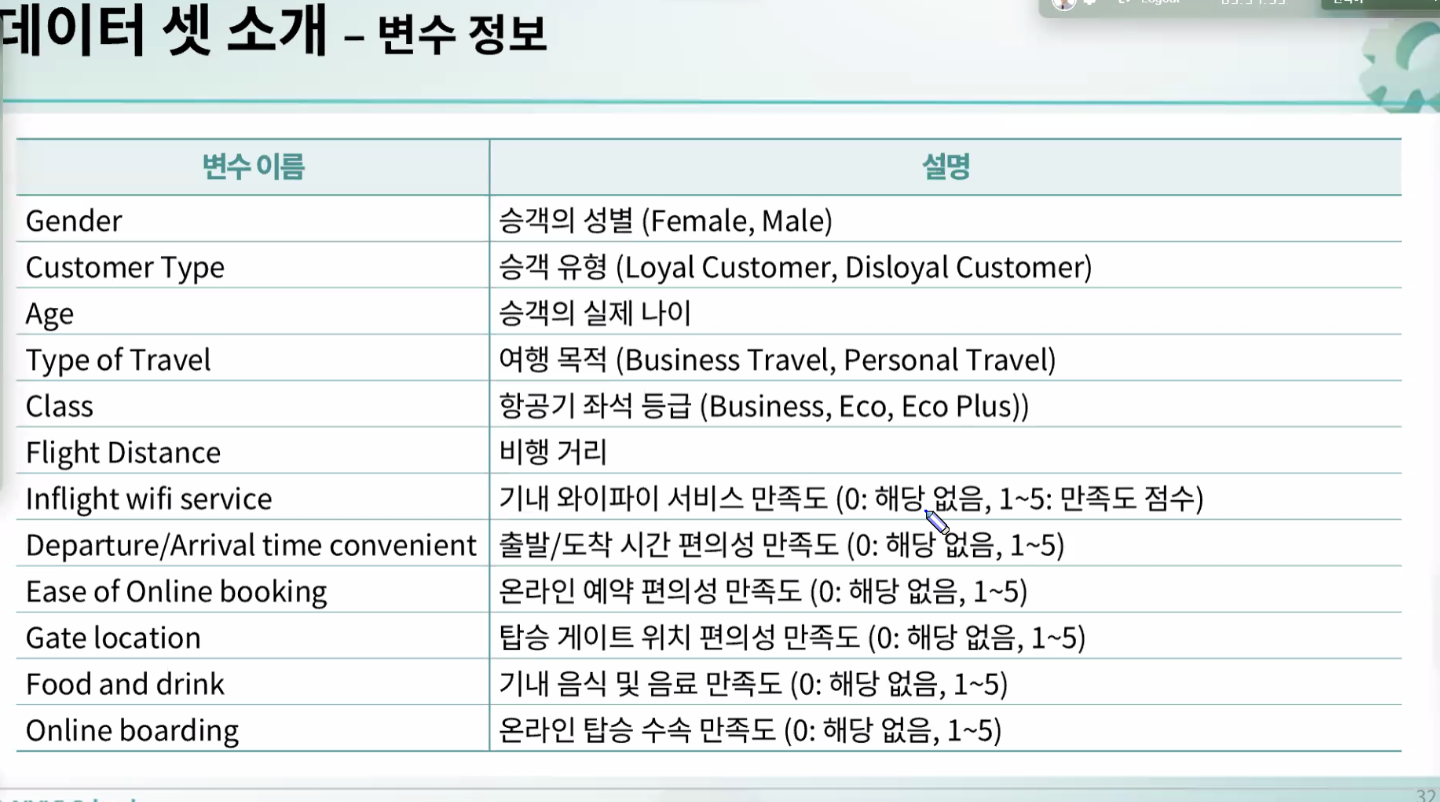

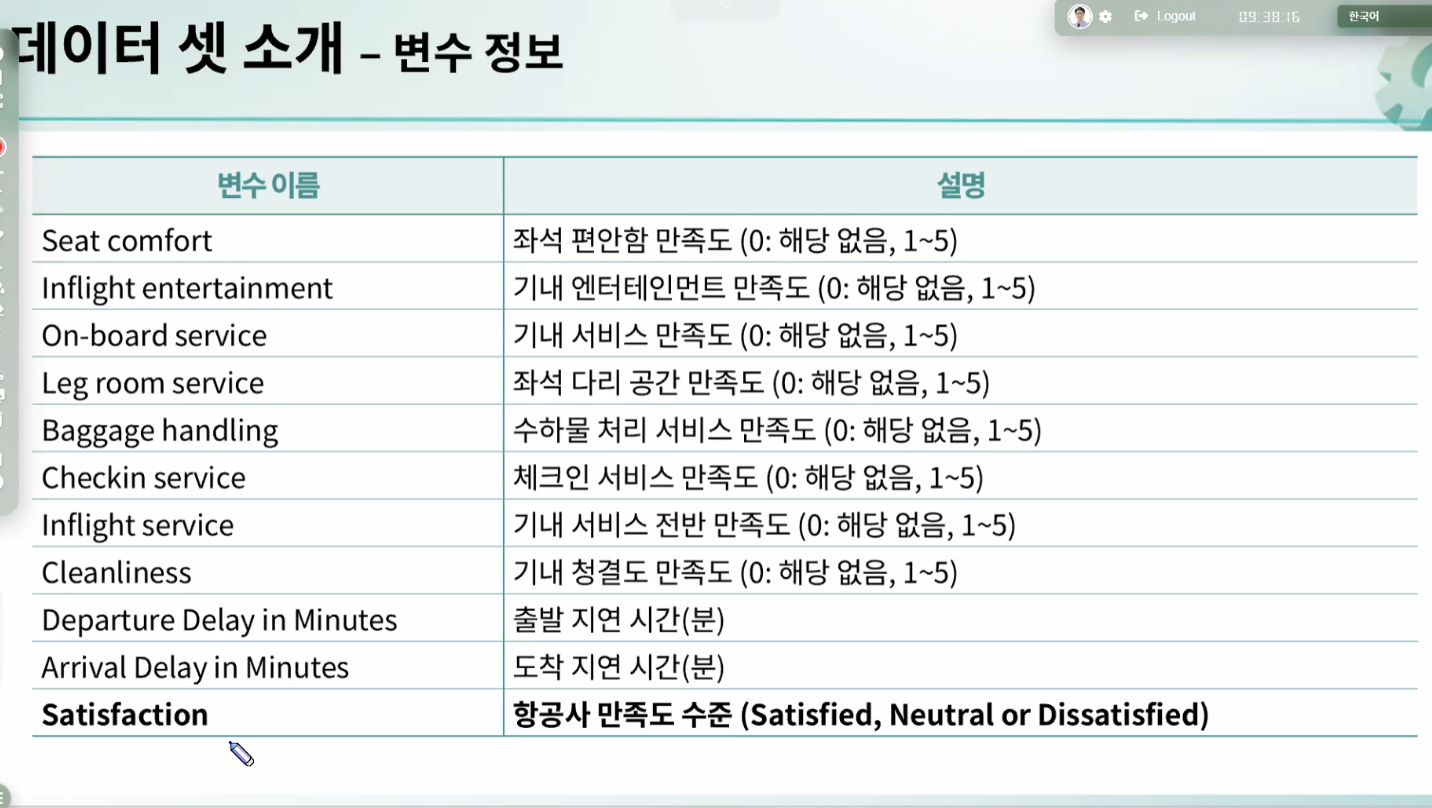

## **2. 미션 1: 기본 탐색 및 전처리**

### (1) 기본정보 확인

- 데이터 형태, 기초통계량 등을 확인합니다.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         19278 non-null  int64  
 1   ID                                 19278 non-null  int64  
 2   Gender                             19278 non-null  object 
 3   Customer Type                      19278 non-null  object 
 4   Age                                18626 non-null  float64
 5   Type of Travel                     19278 non-null  object 
 6   Class                              19278 non-null  object 
 7   Flight Distance                    19278 non-null  int64  
 8   Inflight wifi service              18640 non-null  float64
 9   Departure/Arrival time convenient  19278 non-null  int64  
 10  Ease of Online booking             19278 non-null  int64  
 11  Gate location                      19278 non-null  int

In [6]:
data.describe()

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,19278.000000,19278.000000,18626.000000,19278.000000,18640.000000,19278.000000,19278.000000,19278.000000,18893.000000,19278.000000,18791.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.00000,19278.000000,19278.000000,19278.000000,19224.000000
mean,51926.605716,65515.708580,41.424783,1474.563544,3.094528,2.985631,2.989159,2.989003,3.451596,3.887955,3.876111,3.853512,3.776118,3.734983,3.905644,3.58891,3.914981,3.658004,12.802832,12.833645
std,30134.716545,37481.228258,13.166125,1117.574556,1.541379,1.542553,1.540798,1.353441,1.260715,1.251155,1.193953,1.150868,1.170431,1.214783,1.118987,1.18149,1.116209,1.187601,34.104475,34.531938
min,13.000000,4.000000,7.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000
25%,25716.500000,33204.750000,32.000000,495.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,0.000000,0.000000
50%,51992.500000,65640.500000,43.000000,1119.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,0.000000,0.000000
75%,78115.250000,97865.250000,51.000000,2321.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,9.000000,9.000000
max,103901.000000,129867.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,933.000000,920.000000


In [7]:
data.shape

(19278, 25)

### (2) Target 변수 확인

- Target인 **Satisfaction** 변수에 대해 단변량 분석을 수행합니다.

In [8]:
print(data['Satisfaction'].value_counts())
print(data['Satisfaction'].value_counts(normalize=True))

Satisfaction
Satisfied                  17293
Neutral or Dissatisfied     1985
Name: count, dtype: int64
Satisfaction
Satisfied                  0.897033
Neutral or Dissatisfied    0.102967
Name: proportion, dtype: float64


In [9]:
A = data['Satisfaction']

print(A)
print(A.info())
print(A.describe())
print(A.isnull().sum())

0        Satisfied
1        Satisfied
2        Satisfied
3        Satisfied
4        Satisfied
           ...    
19273    Satisfied
19274    Satisfied
19275    Satisfied
19276    Satisfied
19277    Satisfied
Name: Satisfaction, Length: 19278, dtype: object
<class 'pandas.core.series.Series'>
RangeIndex: 19278 entries, 0 to 19277
Series name: Satisfaction
Non-Null Count  Dtype 
--------------  ----- 
19278 non-null  object
dtypes: object(1)
memory usage: 150.7+ KB
None
count         19278
unique            2
top       Satisfied
freq          17293
Name: Satisfaction, dtype: object
0


### (3) 결측치 확인

- 결측치 비율을 기준으로 내림차순 정렬해 확인합니다.

In [10]:
data.isnull().sum()

,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,652
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,638
Departure/Arrival time convenient,0


### (4) 결측치 채우기

- 결측치가 있는 수치형 변수는 **중앙값**으로, 범주형 변수는 **최빈값**으로 채웁니다.
    - 수치형 변수: 'Age', 'Arrival Delay in Minutes'
    - 범주형 변수: 'Inflight wifi service', 'Seat comfort', 'Food and drink'
- 추천: 이후 확장성을 위해 범주형/수치형 변수를 자동 선택하고, 결측치를 일괄 처리합니다.

In [11]:
# 수치형 변수 선택
num_cols = data.select_dtypes(include=['number']).columns

# 결측치 → 중앙값
for col in num_cols:
  median_val = data[col].median()             # 수치형 변수들의 중앙값 처리
  data[col].fillna(median_val, inplace=True)  # 결측치들을 중앙값으로 채우고 덮어씌우기

In [12]:
# 범주형 변수 선택
cat_cols = data.select_dtypes(include=['object', 'category']).columns

# 결측치 → 최빈값
for col in cat_cols:
  mode_v = data[col].mode()               # 범주형 변수들의 최빈값 처리
  data[col].fillna(mode_v, inplace=True) # 결측치들을 최빈값으로 채우고 덮어씌우기

### (5) Target 값 변경

- Target인 **Satisfaction** 변수  값을 1과 0으로 변경합니다.
    - 'Satisfied'--> 1,
    - 'Neutral or Dissatisfied' --> 0
- **map()** 메서드를 사용합니다.

In [13]:
# Target -> Satisfaction 값을 1과 0 바꾸자잉
data['Satisfaction'] = data['Satisfaction'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

print(data['Satisfaction'].value_counts())

Satisfaction
1    17293
0     1985
Name: count, dtype: int64


### (6) 불필요한 변수 제거

- 다음 변수는 분석에 의미가 없으므로 제거합니다.
    - 'Unnamed: 0'
    - 'ID'

In [14]:
# 불필요한 변수 제거
data.drop(columns=['Unnamed: 0', 'ID'], axis=1, inplace=True)
print(data.columns)

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'Satisfaction'],
      dtype='object')


## **3. 미션 2: 가설 수립과 검증**

### (1) 가설 수립

- 'ㅇㅇ이면 ㅇㅇ일 것이다' 라는 형식의 가설을 5개 이상 세워봅니다.
- 이후 분석 과정을 통해 수립한 가설을 검증합니다.
- 특히 이변량 분석을 통해 가설을 검증하도록 합니다.

In [15]:
# 가설 1: 여행 목적(Type of Travel):  비즈니스인 고객 그룹은 개인 여행그룹보다 서비스 품질에 더 민감하여, 전체 만족도가 더 높게 나타날 것이다
# 가설 2: 비행 거리 : 거리가 길어질수록 기내 체류 시간이 늘어남에 따라 피로도 상승으로 인해 전체 만족도는 점차 감소할 것이다
# 가설 3: 출발/도착 시간 편의성 만족도 : 편의성에 따라 점수가 높을 수록 만족도도 긍정적인 영향을 미칠 것이다
# 가설 4: 좌석 편안함 만족도 : 좌석 편안함에 따라 물리적으로 다른 부가 서비스보다 전체 만족도 결정에 더 높은 중요도를 끼칠 것이다
# 가설 5: 출발 지연 시간 : 출발 지연 시간이 늘어남에 따라 만족도도 줄어들 것이다

### (2) 단변량 분석

- 5개 이상의 변수에 대한 단변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

In [16]:
data.head(3) #확인

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,1,1,...,5,4,2,2,3,1,5,0,0.0,1
1,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,1,1,...,4,4,4,4,5,4,5,10,3.0,1
2,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,1,1,...,4,4,4,4,2,4,4,21,7.0,1


In [17]:
data.describe() #확인 -> 시각화 준비

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
count,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.00000,19278.000000,19278.000000,19278.000000,19278.000000,19278.000000
mean,41.478058,1474.563544,3.091400,2.985631,2.989159,2.989003,3.462548,3.887955,3.879241,3.853512,3.776118,3.734983,3.905644,3.58891,3.914981,3.658004,12.802832,12.797697,0.897033
std,12.944685,1117.574556,1.515751,1.542553,1.540798,1.353441,1.250418,1.251155,1.178935,1.150868,1.170431,1.214783,1.118987,1.18149,1.116209,1.187601,34.104475,34.490208,0.303924
min,7.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,32.000000,495.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,0.000000,0.000000,1.000000
50%,43.000000,1119.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,0.000000,0.000000,1.000000
75%,51.000000,2321.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,9.000000,9.000000,1.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,933.000000,920.000000,1.000000


[Type of Travel 빈도/비율]
Type of Travel
Business Travel    0.884998
Personal Travel    0.115002
Name: proportion, dtype: float64

[Flight Distance 요약]
count    19278.000000
mean      1474.563544
std       1117.574556
min         56.000000
25%        495.000000
50%       1119.000000
75%       2321.000000
max       4983.000000
Name: Flight Distance, dtype: float64

[Departure/Arrival time convenient 요약]
count    19278.000000
mean         2.985631
std          1.542553
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: Departure/Arrival time convenient, dtype: float64

[Seat comfort 빈도/비율]
Seat comfort
4.0    0.395788
5.0    0.351904
3.0    0.101515
2.0    0.081232
1.0    0.069561
Name: proportion, dtype: float64

[Departure Delay in Minutes 요약]
count    19278.000000
mean        12.802832
std         34.104475
min          0.000000
25%          0.000000
50%          0.000000
75%          9.000000
max        933.000000
Name: De

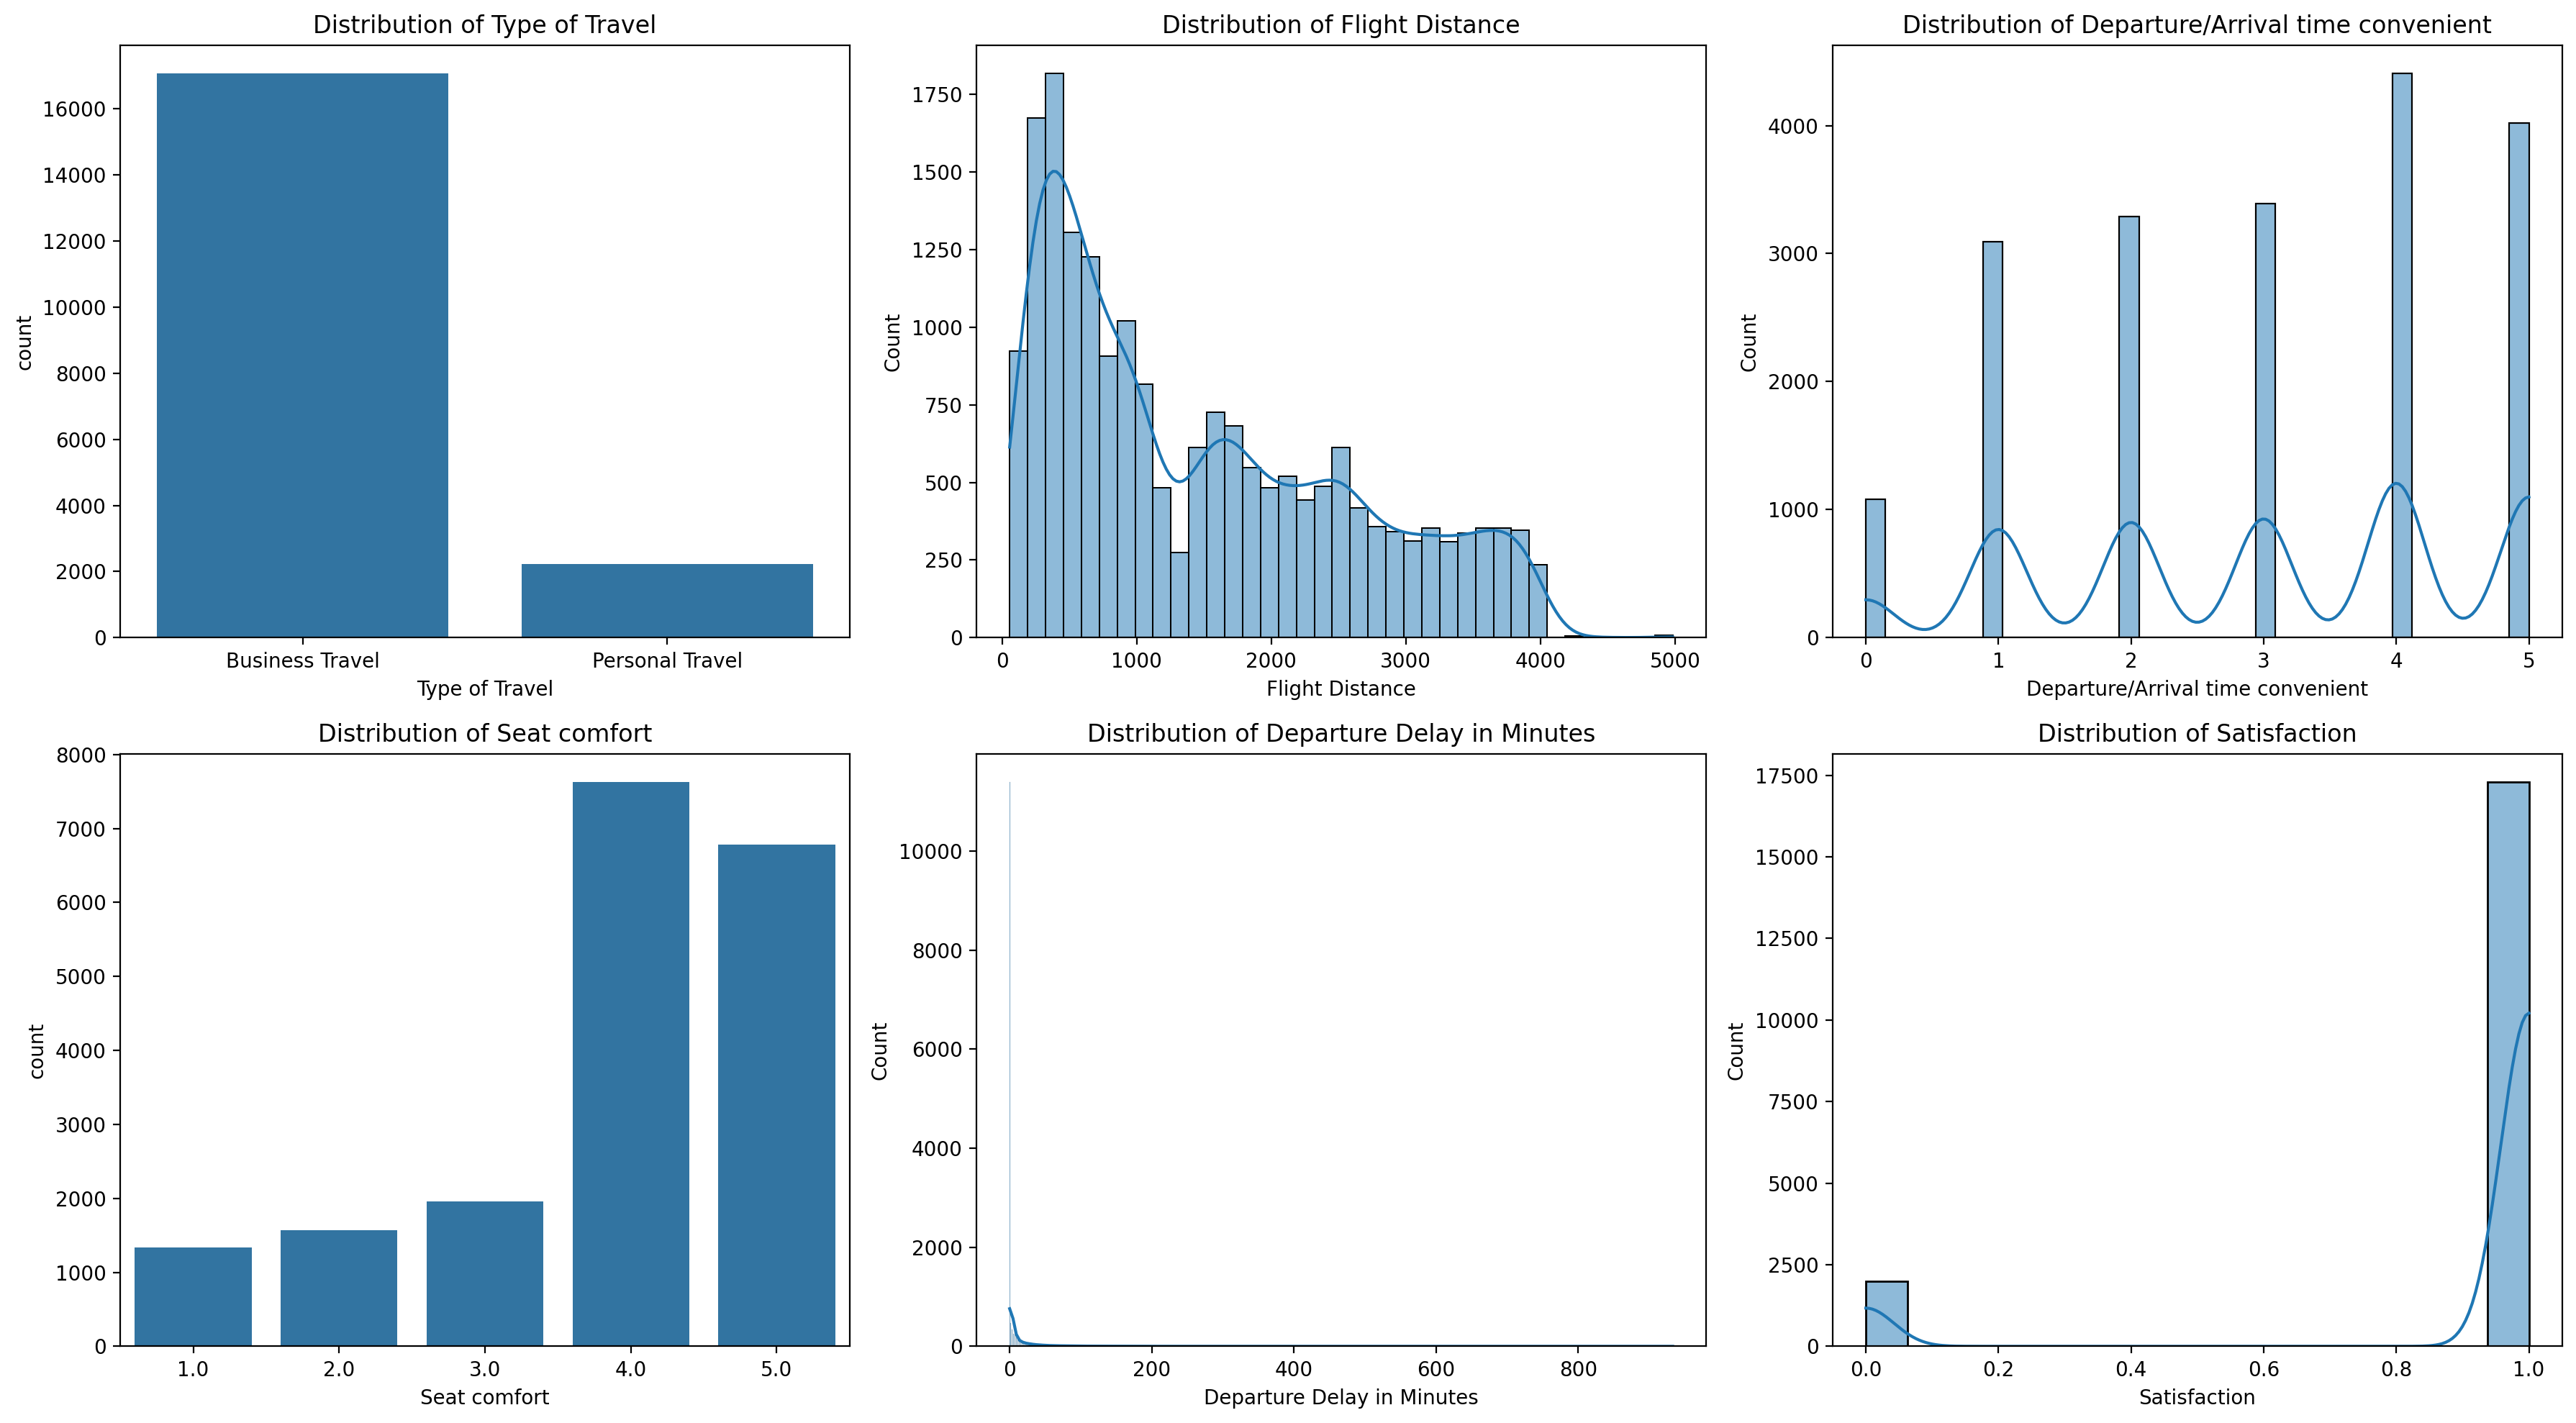

In [18]:
# 시각화 틀 생성 (2행 3열)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 변수 리스트 (가설 관련 5개 + 타겟 1개)
cols = ['Type of Travel', 'Flight Distance', 'Departure/Arrival time convenient',
        'Seat comfort', 'Departure Delay in Minutes', 'Satisfaction']

for i, col in enumerate(cols):
    # 수치형 데이터 (가설 2, 5)
    if data[col].dtype in ['int64', 'float64'] and col != 'Seat comfort': # 점수형 제외
        sns.histplot(data[col], kde=True, ax=axes[i])
        print(f"[{col} 요약]\n{data[col].describe()}\n")

    # 범주형 및 점수형 데이터 (가설 1, 3, 4, 타겟)
    else:
        sns.countplot(x=data[col], ax=axes[i])
        print(f"[{col} 빈도/비율]\n{data[col].value_counts(normalize=True)}\n")
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# 타겟 변수 : 앞서 확인했듯이 데이터 불균형이 9:1로 심각하다

# 가설1 변수 (여행 목적 / Type of Travel)
# : 여행 목적은 비즈니스그룹과 개인 여행그룹이 약 9:1로 나뉘어져 있다
# 가설2 변수 (비행 거리 / Flight Distance)
# : 해당 변수는 연속형 변수이며, 양의 왜도를 갖고 있으며 평균값보다 중앙값이 더 의미 있을 수치이다
# 따라서, 스케일링이 로그 스케일링이 더 필요해 보인다
# 가설3 변수 (출발/도착 시간 편의성 / Departure/Arrival time convenient)
# : 0~5로 구성되어 있으며 0이 제일 적고 (해당없음), 1,2,3,5,4,순으로 크다
# 가설4 변수 (좌석 편안함 / Seat comfort)
# : 4,5가 월등히 크고 1,2,3 수치는 작다
# 가설5 변수 (출발 지연 시간 / Departure Delay in Minutes)
# : 박스플롯을 그려봤을 때 사분위 수가 매우 0에 가깝게 위치하고 있다(대부분 정시 출발)
# 허나 이상치들이 강력하게 나타나고 있어 분석할 만한 가치가 있다고 판단

### (3) 이변량 분석

- 5개 이상의 이변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

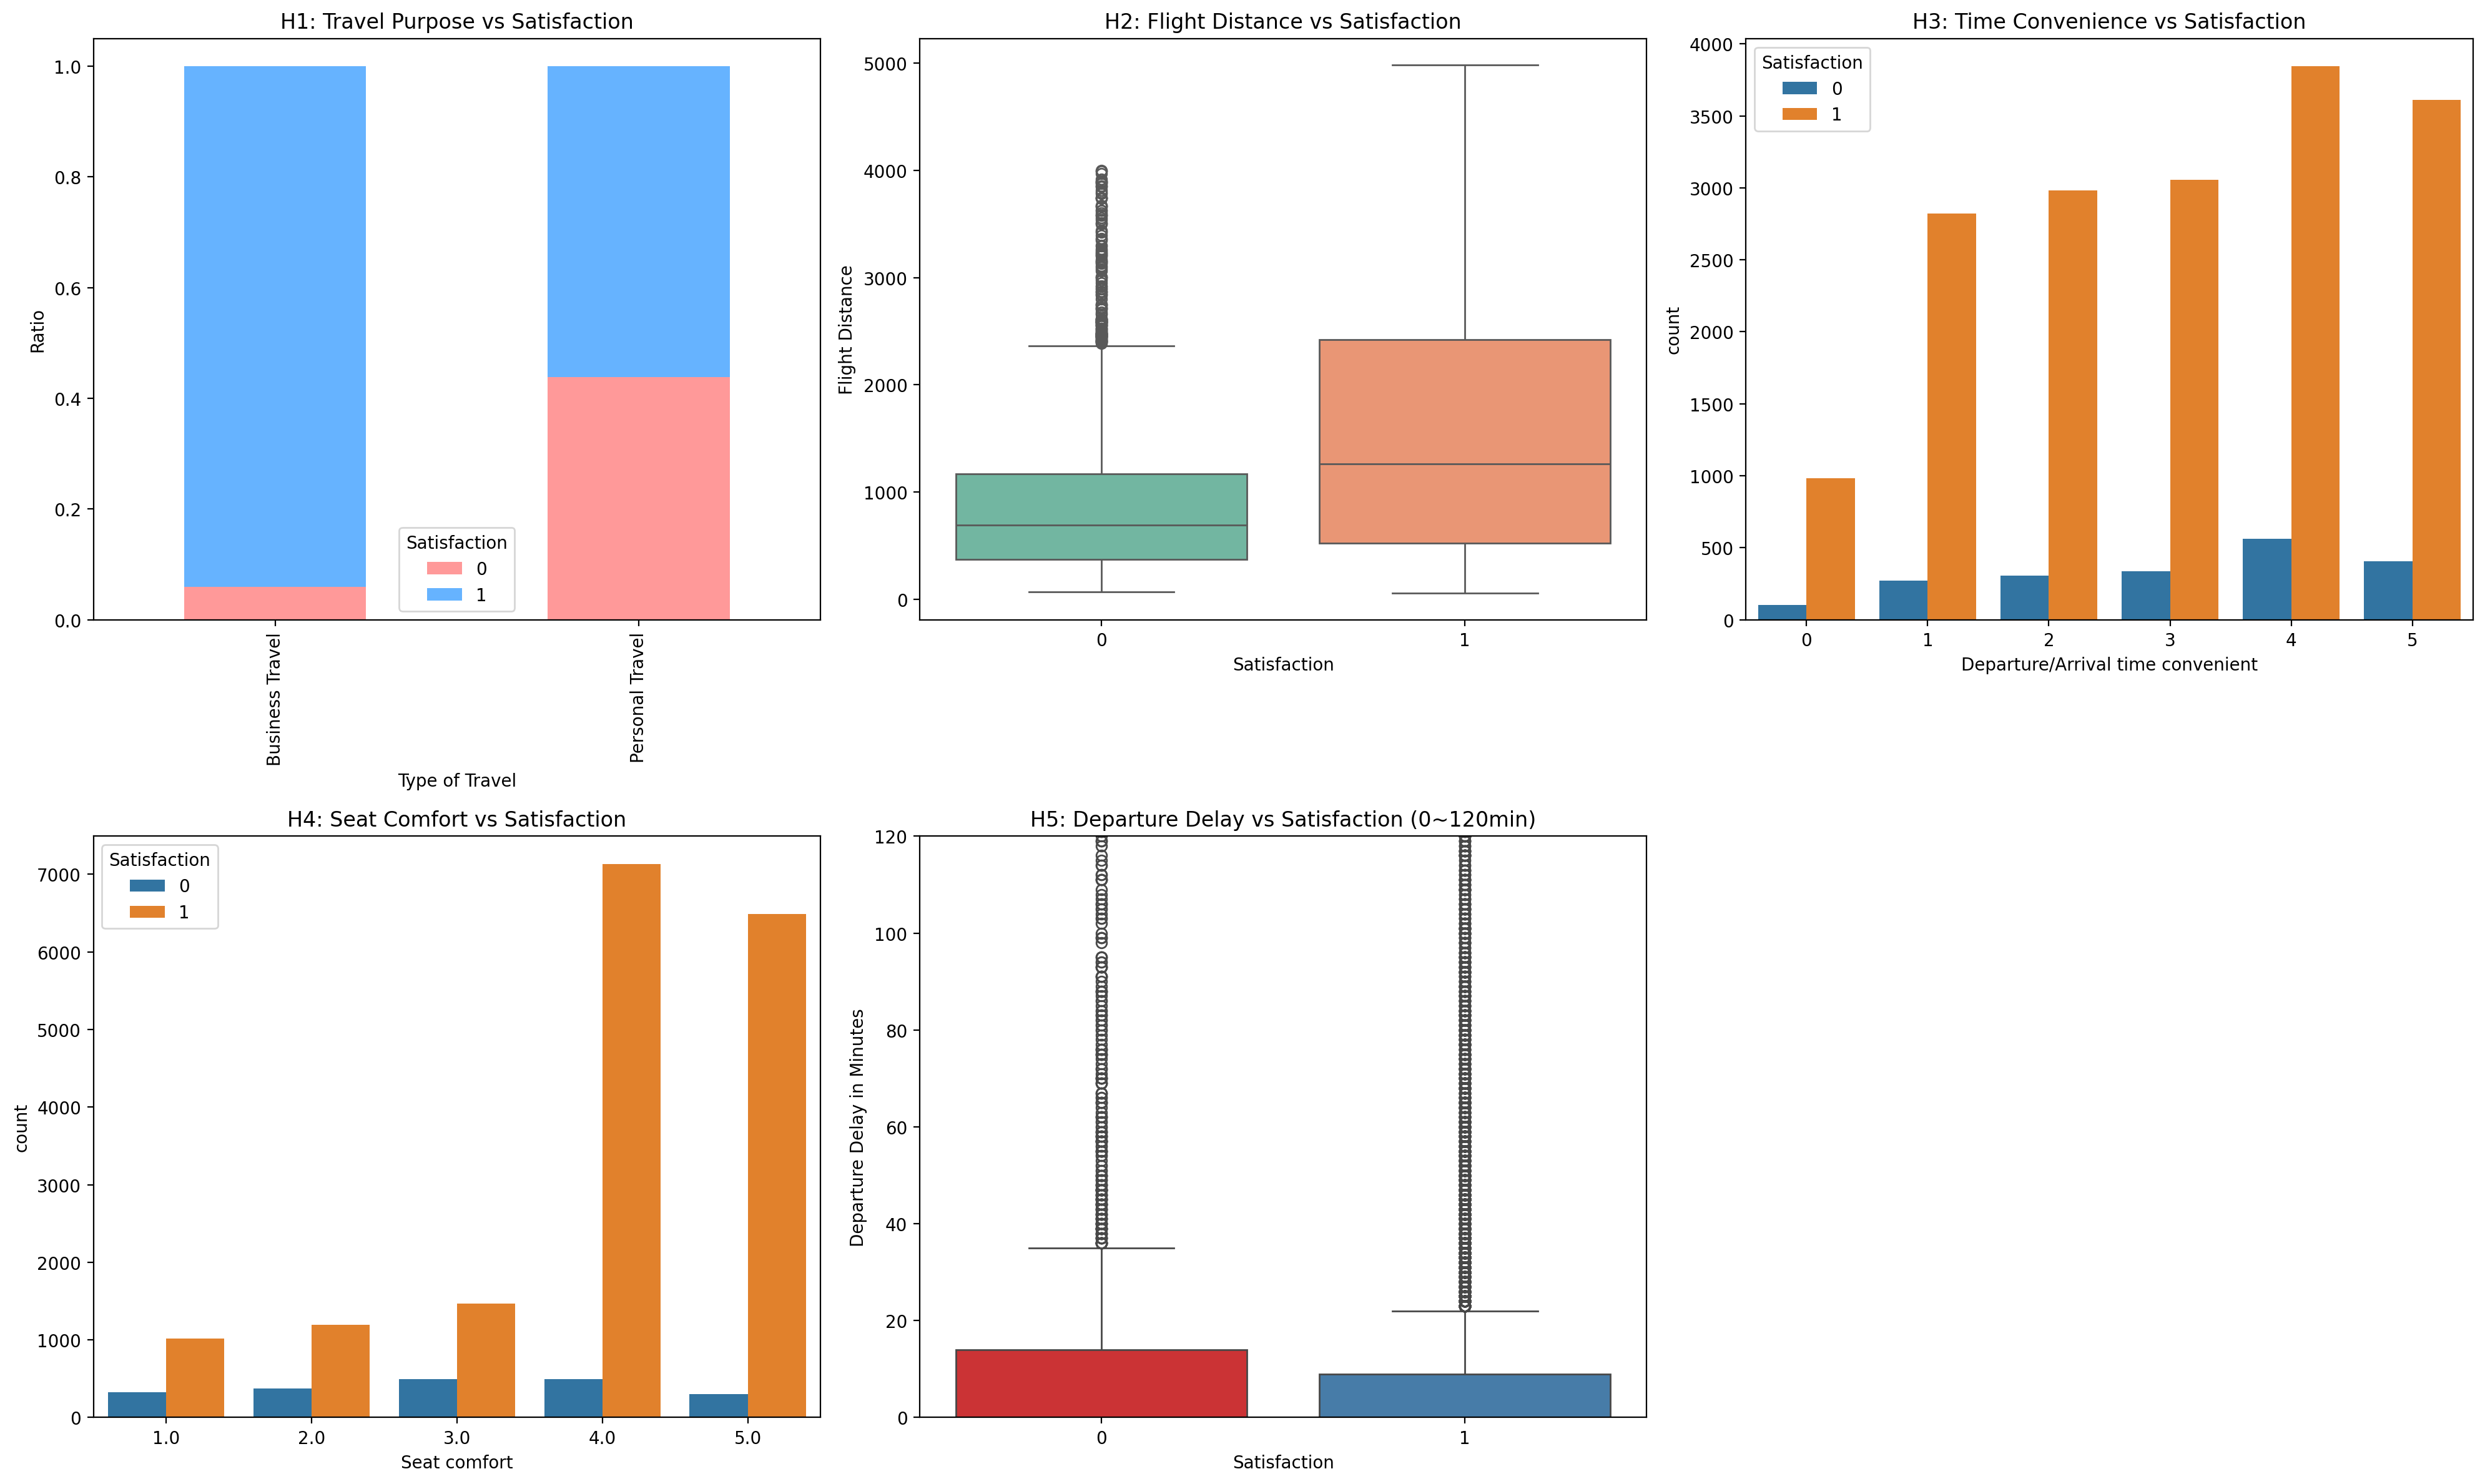

In [19]:
# 1. 시각화 준비 (위 3개, 아래 2개 배치)
plt.figure(figsize=(20, 12))

# --- 가설 1: 여행 목적 (범주형 vs 범주형) ---
plt.subplot(2, 3, 1)
# 비율로 변환하여 Stacked Bar Plot 시각화
travel_satisfaction = pd.crosstab(data['Type of Travel'], data['Satisfaction'], normalize='index')
travel_satisfaction.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#ff9999','#66b3ff'])
plt.title('H1: Travel Purpose vs Satisfaction')
plt.ylabel('Ratio')

# --- 가설 2: 비행 거리 (수치형 vs 범주형) ---
plt.subplot(2, 3, 2)
sns.boxplot(x='Satisfaction', y='Flight Distance', data=data, palette='Set2')
plt.title('H2: Flight Distance vs Satisfaction')

# --- 가설 3: 시간 편의성 (점수형 vs 범주형) ---
plt.subplot(2, 3, 3)
# 점수(0~5)별로 만족도 비중 확인
sns.countplot(x='Departure/Arrival time convenient', hue='Satisfaction', data=data)
plt.title('H3: Time Convenience vs Satisfaction')

# --- 가설 4: 좌석 편안함 (점수형 vs 범주형) ---
plt.subplot(2, 3, 4)
sns.countplot(x='Seat comfort', hue='Satisfaction', data=data)
plt.title('H4: Seat Comfort vs Satisfaction')

# --- 가설 5: 출발 지연 시간 (수치형 vs 범주형) ---
plt.subplot(2, 3, 5)
# 이상치가 많으므로 y축을 120분으로 제한하여 경향성 파악
sns.boxplot(x='Satisfaction', y='Departure Delay in Minutes', data=data, palette='Set1')
plt.ylim(0, 120)
plt.title('H5: Departure Delay vs Satisfaction (0~120min)')

plt.tight_layout()
plt.show()

# 의견 :
# H1(여행목적) : 불균형 타겟임에도 불구하고 개인여행의 경우가 불만족 비율이 확실히 높다
# H2(비행거리) : 장거리 고객이 만족하는 경우가 더 높다
# H3(편의성) : 편의성이 높을 수록 만족도가 높긴하지만 불만족의 분포 비율도 비슷하기에 확실치 않다
# H4(좌석) : 상동
# H5(지연시간) : 불균형 데이터임에도 불구하고 지연시간이 길수록 불만족의 그룹이 높게 형성되어있다

## **4. 미션 3: 머신러닝 모델링 #1**

- Tree 기반 알고리즘을 사용해야 **변수 중요도**를 확인할 수 있습니다.
- **RandomForest** 알고리즘을 사용해 머신러닝 모델을 만들고 성능을 평가합니다.
- **변수 중요도**를 확인해 추가 분석 대상 변수를 선정합니다.

### (1) 전처리

- 최소한 문자열 데이터가 없어야 하고, 결측치도 없도록 전처리해야 합니다.
- 결측치는 이전 단계에서 처리한 상태입니다.
- 범주형 변수에 대해 **LabelEncoder**를 사용해 인코딩합니다.
- 변수 중요도를 확인하기 위함이므로 가변수화를 하지 않습니다.

In [20]:
# 변수 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  object 
 1   Customer Type                      19278 non-null  object 
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  object 
 4   Class                              19278 non-null  object 
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

In [21]:
# 문자열 변수 리스트로 선언
cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# 라벨 인코딩
for col in cat_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])

- info() 메서드로 변수 정보를 다시 확인합니다.
- **Dtype에 object 형식의 열이 있으면 이후 과정을 진행할 수 없습니다.**

In [22]:
# 인코딩 확인
data.info() # object 사라짐

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  int64  
 1   Customer Type                      19278 non-null  int64  
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  int64  
 4   Class                              19278 non-null  int64  
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

- target 변수를 선정하고 x, y를 분리합니다.

In [23]:
# 타겟 지정
target = 'Satisfaction'

# 데이터 분리
x = data.drop(target, axis=1)
y = data.loc[:, target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [24]:
# 라이브러리 생략 (위에서 선언함)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3,  stratify=y, random_state=1)

### (2) 모델링

- 머신러닝 모델링을 수행합니다.
- 검증 데이터로 예측하고 성능을 평가해 봅니다.

In [25]:
# x 행열 확인 다시
x.shape

(19278, 22)

In [26]:
# RandomForestClassifier 모델 생성 및 학습 -> 모든 모델 동일한 모델 사용 예정
model = RandomForestClassifier(max_depth=10, random_state = 1)

In [27]:
#모델 학습
model.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, random_state=1)

In [28]:
# 예측 및 성능 평가
y_pred = model.predict(x_val)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81       596
           1       0.97      0.99      0.98      5188

    accuracy                           0.96      5784
   macro avg       0.94      0.86      0.89      5784
weighted avg       0.96      0.96      0.96      5784



### (3) 변수 중요도 확인

- 변수 중요도를 시각화해 확인합니다.

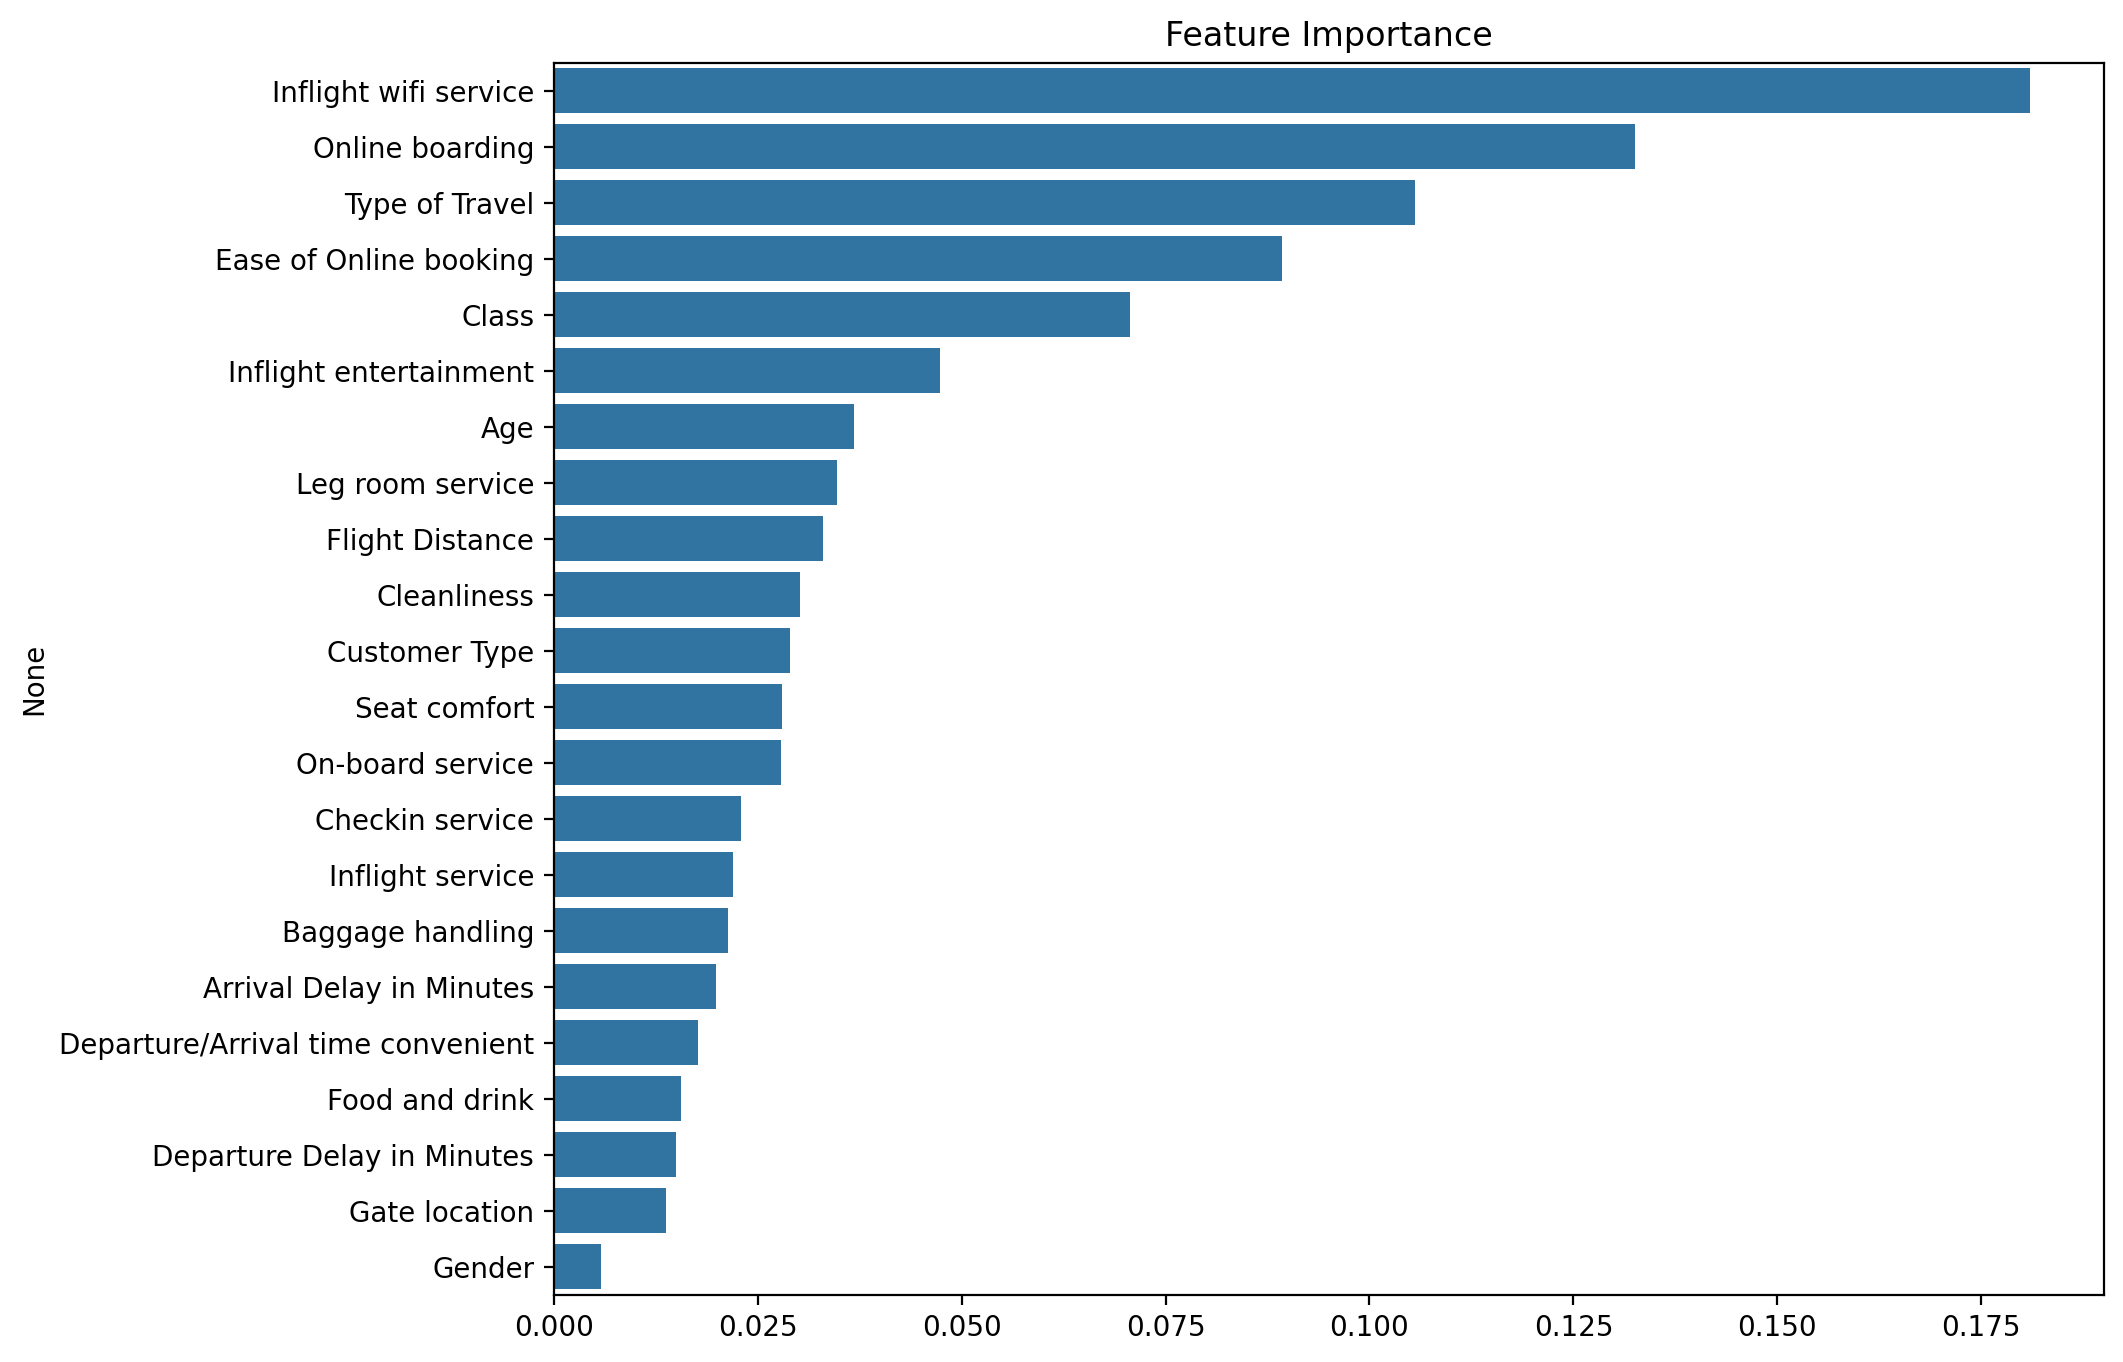

In [29]:
# 변수 중요도 확인
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 중요도 추출 및 Series 제작 (x_train의 컬럼명을 인덱스로 사용)
fi = pd.Series(model.feature_importances_, index=x_train.columns)
fi = fi.sort_values(ascending=False) # 높은 순으로 정렬

# 2. 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=fi.values, y=fi.index) # x에는 중요도 값, y에는 변수 이름

plt.title('Feature Importance')
plt.show()

### (4) 결과 정리

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [30]:
# 가장 중요하다고 확인된 변수 5개
# 1. Inflight wifi service (기내 와이파이 서비스)
# 2. Online boarding (온라인 체크인/탑승)
# 3. Type of Travel (여행 목적)
# 4. Ease of Online booking (온라인 예약 편의성)
# 5. Class (좌석 등급)

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [31]:
# 가장 중요하지 않다고 확인된 변수 5개
# 1. Gender (성별) - 영향력이 거의 없음
# 2. Gate location (게이트 위치)
# 3. Departure Delay in Minutes (출발 지연 시간)
# 4. Food and drink (식음료)
# 5. Departure/Arrival time convenient (출발/도착 시간 편의성)

## **5. 미션 4: 머신러닝 모델링 #2**

- 35세를 기준으로 데이터를 분리해 각각에 대한 모델을 만들어봅니다.

### (1) 데이터 분리

- 더 세분화할 수 있지만, 35세를 기준으로 두 개의 데이터프레임을 만듭니다.
    - **data01**: Age <= 35
    - **data02**: Age > 35

In [32]:
# 1. 35세 이하 데이터 분리
data01 = data[data['Age'] <= 35]

# 2. 35세 초과 데이터 분리
data02 = data[data['Age'] > 35]

# 결과 확인 (데이터 개수 확인)
print(f"data01 (35세 이하) 개수: {len(data01)}")
print(f"data02 (35세 초과) 개수: {len(data02)}")

data01 (35세 이하) 개수: 5830
data02 (35세 초과) 개수: 13448


### (2) 35세 이하 모델링

- **data01** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [33]:
target = 'Satisfaction'
x = data01.drop(target, axis=1)
y = data01[target]

# 분리 확인
print(x.shape)
print(y.shape)

(5830, 22)
(5830,)


- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=1)

- 모델링을 수행합니다.

In [35]:
# 모델 선언
model01 = RandomForestClassifier(max_depth=10, random_state=1)

In [36]:
# 모델 학습
model01.fit(x_train,y_train)

RandomForestClassifier(max_depth=10, random_state=1)

In [38]:
# 예측 및 성능 평가
y_pred = model01.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.80      0.87       274
           1       0.96      0.99      0.98      1475

    accuracy                           0.96      1749
   macro avg       0.95      0.90      0.92      1749
weighted avg       0.96      0.96      0.96      1749



- 변수 중요도를 확인합니다.

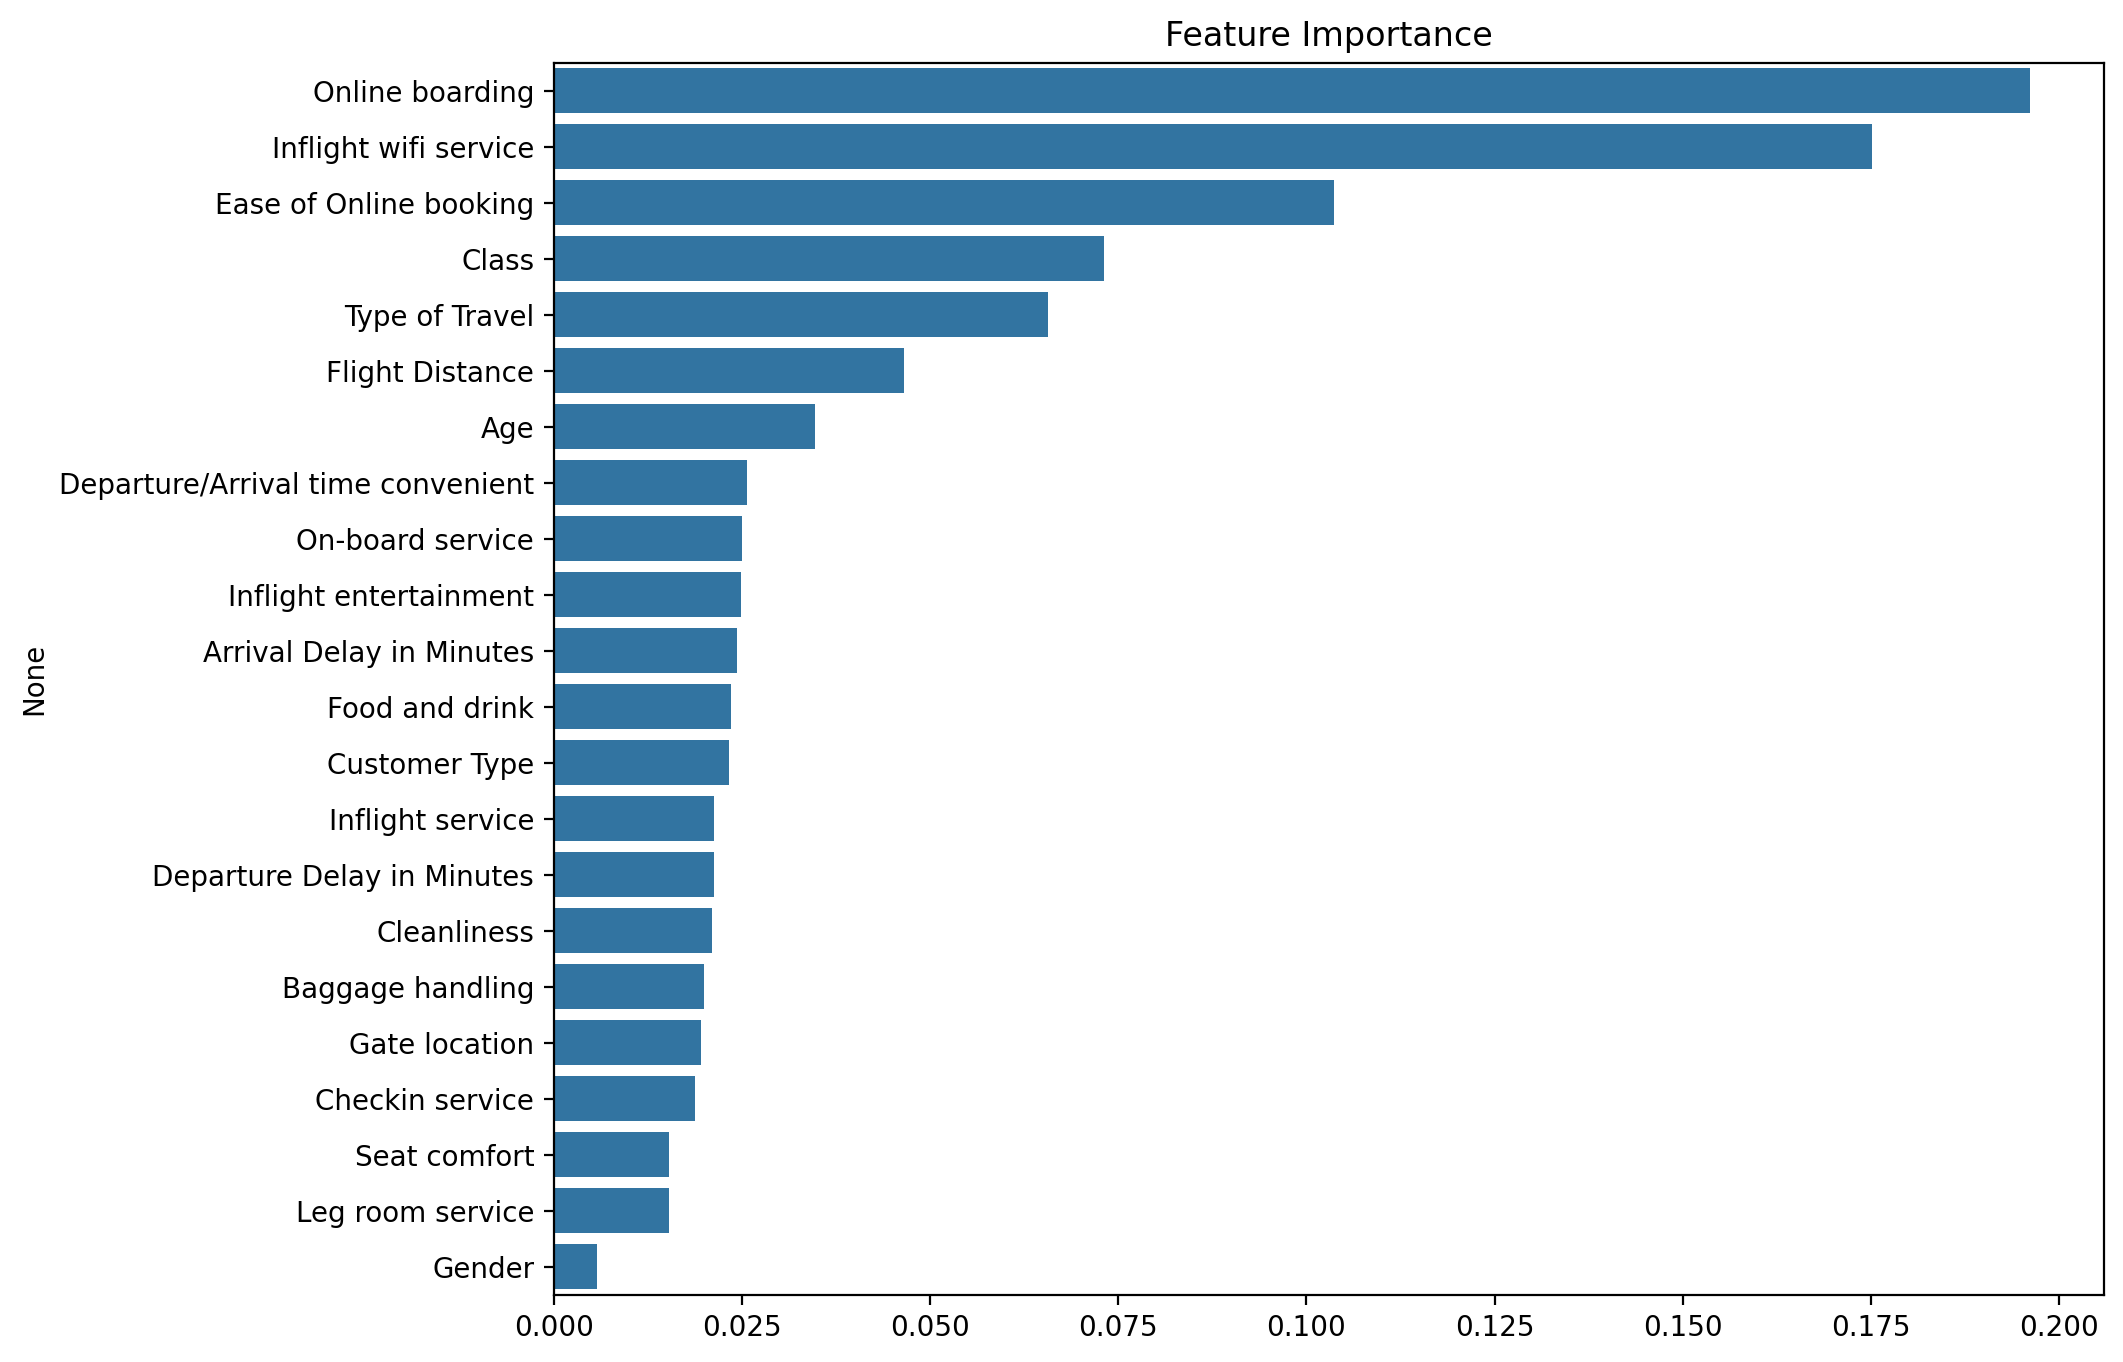

In [56]:
# 변수 중요도 확인
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 중요도 추출 및 Series 제작 (x_train의 컬럼명을 인덱스로 사용)
fi = pd.Series(model01.feature_importances_, index=x_train.columns)
fi = fi.sort_values(ascending=False) # 높은 순으로 정렬

# 2. 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=fi.values, y=fi.index) # x에는 중요도 값, y에는 변수 이름

plt.title('Feature Importance')
plt.show()

- 중요하다고 확인된 변수 5개는 무엇인가요?


In [40]:
# 가장 중요하다고 확인된 변수 5개 (Age <= 35)
# 1. Online boarding (온라인 탑승 수속 만족도)
# 2. Inflight wifi service (기내 와이파이 서비스 만족도)
# 3. Ease of Online booking (온라인 예약 편의성 만족도)
# 4. Class (항공기 좌석 등급)
# 5. Type of Travel (여행 목적)

- 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [41]:
# 가장 중요하지 않다고 확인된 변수 5개 (Age <= 35)
# 1. Gender (승객의 성별)
# 2. Leg room service (좌석 다리 공간 만족도)
# 3. Seat comfort (좌석 편안함 만족도)
# 4. Checkin service (체크인 서비스 만족도)
# 5. Gate location (탑승 게이트 위치 편의성 만족도)

### (3) 35세 초과 모델링

- **data02** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [42]:
# target 변수 선정 및 x, y 분리
target = 'Satisfaction'
x = data02.drop(target, axis=1)
y = data02[target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=1)

- 모델링을 수행합니다.

In [44]:
# 모델 선언
model02 = RandomForestClassifier(max_depth=10, random_state=1)

In [45]:
# 모델 학습
model02.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, random_state=1)

In [46]:
# 예측 및 성능 평가
y_pred = model02.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.72      0.79       321
           1       0.98      0.99      0.98      3714

    accuracy                           0.97      4035
   macro avg       0.92      0.86      0.89      4035
weighted avg       0.97      0.97      0.97      4035



- 변수 중요도를 확인합니다.

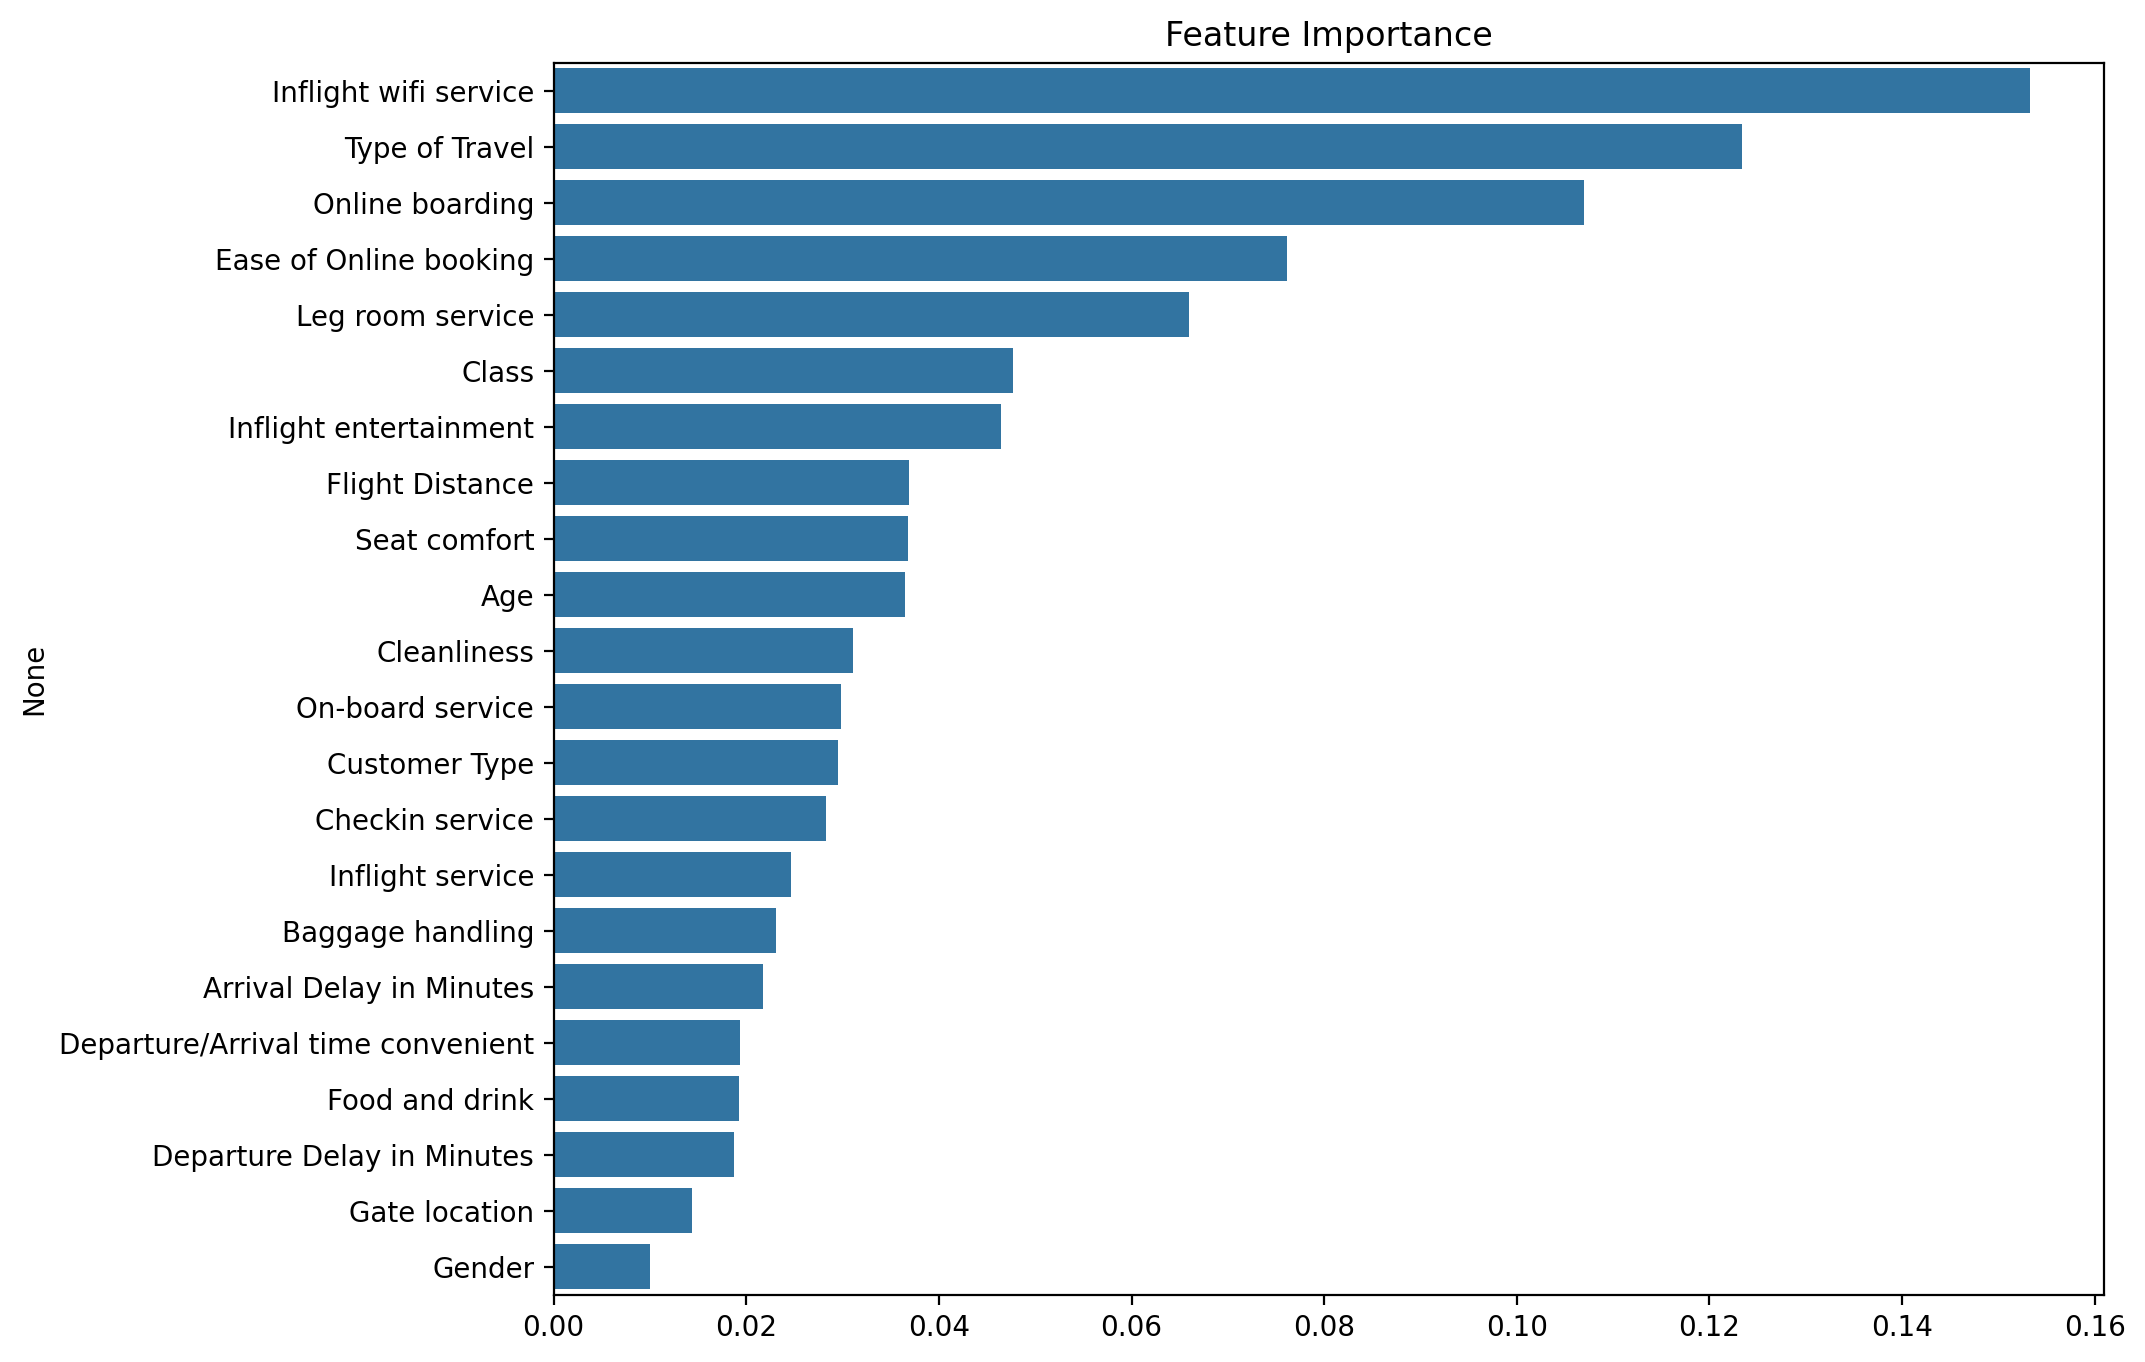

In [55]:
# 변수 중요도 확인
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 중요도 추출 및 Series 제작 (x_train의 컬럼명을 인덱스로 사용)
fi = pd.Series(model02.feature_importances_, index=x_train.columns)
fi = fi.sort_values(ascending=False) # 높은 순으로 정렬

# 2. 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=fi.values, y=fi.index) # x에는 중요도 값, y에는 변수 이름

plt.title('Feature Importance')
plt.show()

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [48]:
# 가장 중요하다고 확인된 변수 5개 (Age > 35)
# 1. Inflight wifi service (기내 와이파이 서비스)
# 2. Type of Travel (여행 목적)
# 3. Online boarding (온라인 탑승 수속)
# 4. Ease of Online booking (온라인 예약 편의성)
# 5. Leg room service (좌석 다리 공간 서비스)

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [49]:
# 가장 중요하지 않다고 확인된 변수 5개 (Age > 35)
# 1. Gender (성별)
# 2. Gate location (게이트 위치)
# 3. Departure Delay in Minutes (출발 지연 시간)
# 4. Food and drink (식음료)
# 5. Departure/Arrival time convenient (출발/도착 시간 편의성)

### (4) 의견 정리

- 위 모델링 과정과 변수 중요도 확인 과정 결과에 대한 의견을 정리합니다.

## 변수 중요도 정리

#### 전체 데이터 모델
| 구분 | 중요도 상위 5개 변수 | 중요도 하위 5개 변수 |
|---|---|---|
| **변수** | 1. Inflight wifi service <br> 2. Online boarding <br> 3. Type of Travel <br> 4. Ease of Online booking <br> 5. Class | 1. Gender <br> 2. Gate location <br> 3. Departure Delay in Minutes <br> 4. Food and drink <br> 5. Departure/Arrival time convenient |

#### 35세 이하 (Age <= 35) 모델
| 구분 | 중요도 상위 5개 변수 | 중요도 하위 5개 변수 |
|---|---|---|
| **변수** | 1. Online boarding <br> 2. Inflight wifi service <br> 3. Ease of Online booking <br> 4. Class <br> 5. Type of Travel | 1. Gender <br> 2. Leg room service <br> 3. Seat comfort <br> 4. Checkin service <br> 5. Gate location |

#### 35세 이상 (Age > 35) 모델
| 구분 | 중요도 상위 5개 변수 | 중요도 하위 5개 변수 |
|---|---|---|
| **변수** | 1. Inflight wifi service <br> 2. Type of Travel <br> 3. Online boarding <br> 4. Ease of Online booking <br> 5. Leg room service | 1. Gender <br> 2. Gate location <br> 3. Departure Delay in Minutes <br> 4. Food and drink <br> 5. Departure/Arrival time convenient |

In [50]:
# 연령대 상관 없이 와이파이 및 온라인 서비스 만족도가 가장 핵심 피처
# 연령대 별로 차이 있는 것은 35세 이하 : 온라인 탑승수속 및 예약 편의성(Online boarding, Ease of Online booking) / 35세 이상 : 넓은 다리 공간(Leg room service)
# 출발 지연시간 보다는 기내 서비스 및 이용 편의성 관련 피처들이 만족도 예측에 훨씬 결정적 기여 => Inflight wifi service, Online boarding, Ease of Online booking, Type of Travel, Leg room service, Class

## **6. 미션 5: 데이터 분석**

- 위에서 확인된 변수 중요도를 기준으로 분석할 변수를 5개 선정하고 분석을 수행합니다.
- **data** 데이터프레임을 대상으로 분석합니다.
- Satisfaction 변수와의 **이변량 분석**에 중점을 두고 수행합니다.
- 각 분석 결과에 대한 의견을 주석으로 정리합니다.

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  int64  
 1   Customer Type                      19278 non-null  int64  
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  int64  
 4   Class                              19278 non-null  int64  
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

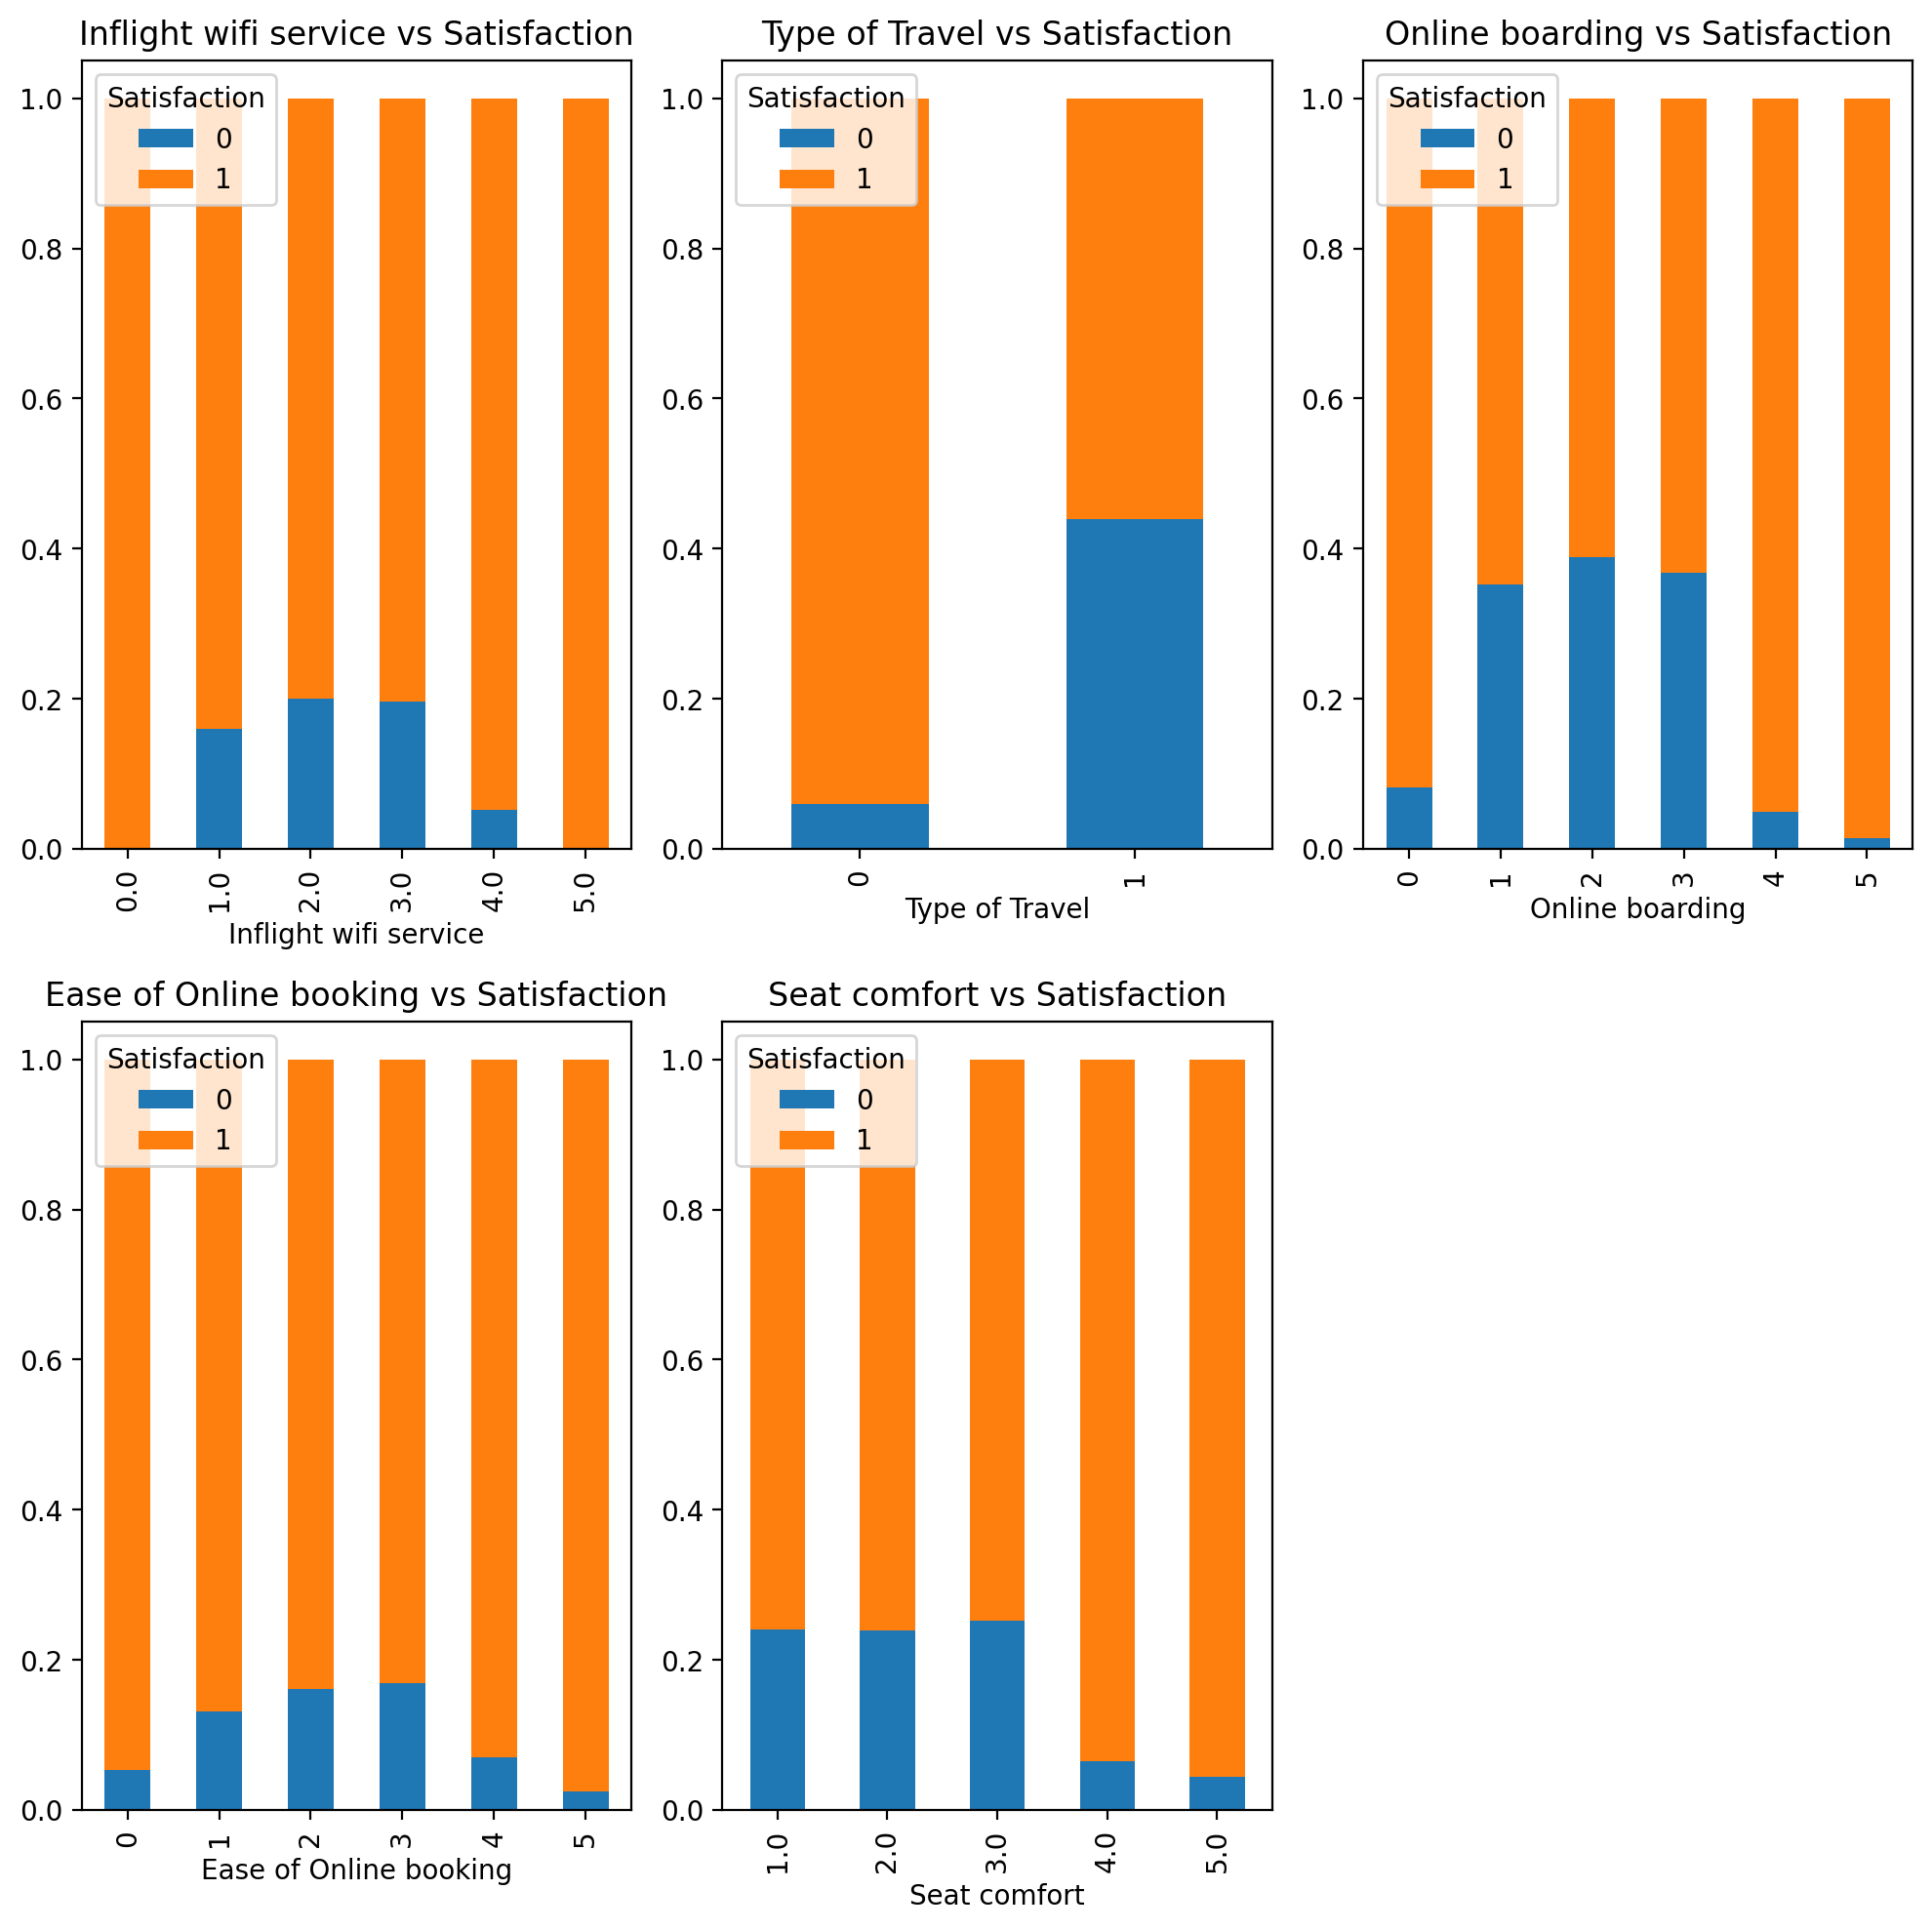

In [53]:
# 1. 분석 대상 변수 선정
top_features = ['Inflight wifi service', 'Type of Travel', 'Online boarding', 'Ease of Online booking', 'Seat comfort']

# 2. 이변량 분석 (Target: Satisfaction) 수행
plt.figure(figsize=(10, 10))

for i, col in enumerate(top_features):
    plt.subplot(2, 3, i+1)

    # 범주형(문자열) vs 범주형 분석
    if data[col].dtype == 'object':
        sns.countplot(x=col, hue='Satisfaction', data=data)
        plt.title(f'{col} vs Satisfaction')

    # 점수형(수치/범주) vs 범주형 분석
    else:
        # 점수별 만족도 비율 확인을 위해 100% 쌓은 막대 그래프 사용
        tmp = pd.crosstab(data[col], data['Satisfaction'], normalize='index')
        tmp.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title(f'{col} vs Satisfaction')
        plt.legend(title='Satisfaction', loc='upper left')

plt.tight_layout()
plt.show()

In [54]:
# 기내 와이파이 서비스 품질이 높을수록 전반적인 만족도가 높은 편이다.
# 개인 여행 목적 승객은 상대적으로 서비스 불만족 비율이 높게 나타난다. => 비용을 직접 부담하는 소비 특성이 영향을 줄 가능성이 있다.
# 온라인 탑승 수속 만족도가 높을수록 전체 만족도도 높게 나타나는 경향이 있다. => 빠르고 편리한 탑승 절차를 중요하게 여기는 것으로 해석된다.
# 온라인 예약 시스템이 편리할수록 만족도가 다소 높은 편이다.
# 좌석 편안함 및 다리 공간 만족도가 높을수록 만족도가 상승하는 경향이 있다. 특히 다리 공간 서비스는 35세 이상 연령층에서 상대적으로 더 중요한 변수로 나타난다.

# => 종합적으로 디지털 서비스(와이파이, 온라인 수속, 예약 편의성)의 품질이 항공사 만족도에 핵심적인 영향을 준다.
# 또한 좌석 편의성(좌석 편안함, 다리 공간) 역시 만족도 향상에 중요한 역할을 한다.
# 현재 데이터는 35세 미만 연령층 비중이 상대적으로 적어 연령대 간 비교 해석에는 한계가 있으므로, 샘플링을 통한 데이터 균형 조정이 필요하다.
# 추가적으로 비즈니스 목적 승객은 개인 여행 승객보다 전반적인 만족도가 높은 편으로 나타난다.

## **7. 저장하기**

- **to_csv()** 메서드를 사용해 이후 과정을 위해 data 데이터프레임을 **project01** 폴더에 저장합니다.
    - index=False 옵션 지정
    - data → path + 'data.csv'
    
- 저장된 파일을 필히 확인합니다.

In [ ]:
data.info()

In [ ]:
# 파일 저장
data.to_csv(path + 'data.csv', index=False)